In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

## 1) Förstå datan

### Fashion MNIST dataset

https://keras.io/api/datasets/fashion_mnist/

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [7]:
print("Träningsbilder (X_train):", X_train.shape)
print("Träningsetiketter (y_train):", y_train.shape)
print("Testbilder (X_test):", X_test.shape)
print("Testetiketter (y_test):", y_test.shape)

Träningsbilder (X_train): (60000, 28, 28)
Träningsetiketter (y_train): (60000,)
Testbilder (X_test): (10000, 28, 28)
Testetiketter (y_test): (10000,)


In [8]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [10]:
antal_per_klass = np.bincount(y_train)

print("Antal bilder per klass:")
for i, antal in enumerate(antal_per_klass):
    print(class_names[i], ":", antal)

Antal bilder per klass:
T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


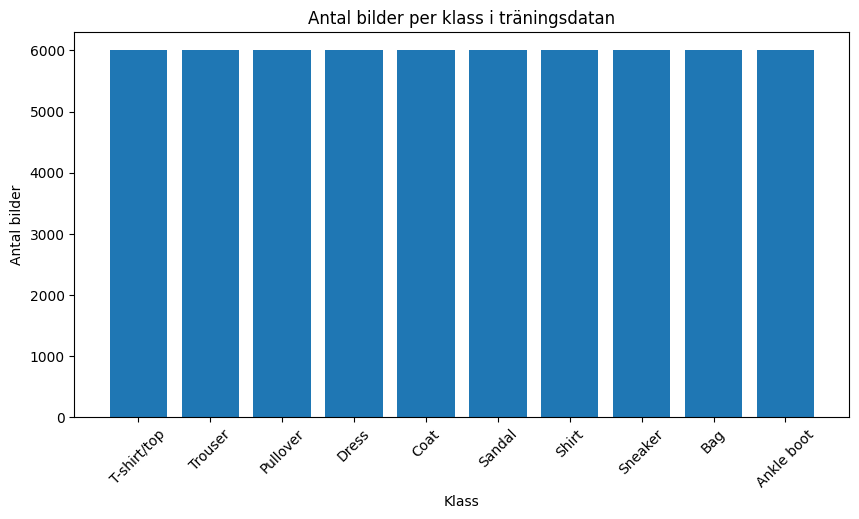

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(class_names, antal_per_klass)
plt.xticks(rotation=45)
plt.title("Antal bilder per klass i träningsdatan")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")
plt.show()

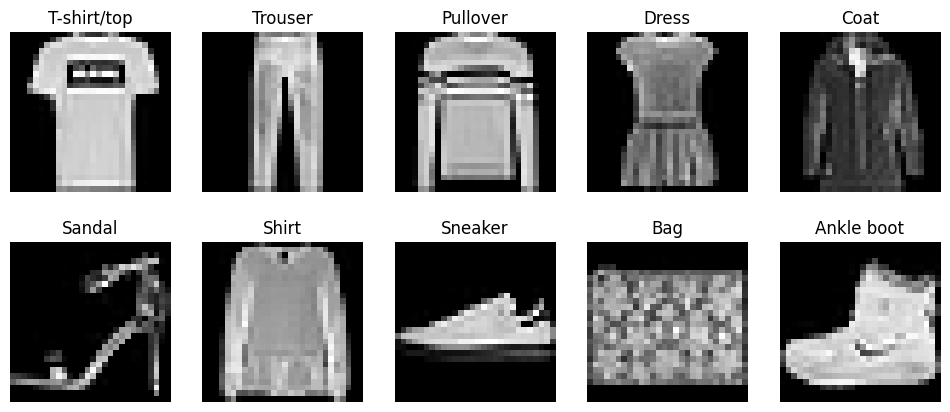

In [14]:
plt.figure(figsize=(12, 5))

for klass in range(10):
    index = np.where(y_train == klass)[0][0]
    plt.subplot(2, 5, klass + 1)
    plt.imshow(X_train[index], cmap="gray")
    plt.title(class_names[klass])
    plt.axis("off")

plt.show()

In [13]:
print("Bildstorlek:", X_train[0].shape)
print("Datatyp:", X_train.dtype)
print("Minsta pixelvärde:", X_train.min())
print("Största pixelvärde:", X_train.max())

Bildstorlek: (28, 28)
Datatyp: uint8
Minsta pixelvärde: 0
Största pixelvärde: 255


In [18]:
# Testdatan

antal_per_klass_test = np.bincount(y_test)

print("Antal bilder per klass:")
for i, antal in enumerate(antal_per_klass_test):
    print(class_names[i], ":", antal)

print("\nBildstorlek:", X_test[0].shape)
print("Datatyp:", X_test.dtype)
print("Minsta pixelvärde:", X_test.min())
print("Största pixelvärde:", X_test.max())

Antal bilder per klass:
T-shirt/top : 1000
Trouser : 1000
Pullover : 1000
Dress : 1000
Coat : 1000
Sandal : 1000
Shirt : 1000
Sneaker : 1000
Bag : 1000
Ankle boot : 1000

Bildstorlek: (28, 28)
Datatyp: uint8
Minsta pixelvärde: 0
Största pixelvärde: 255


## 2) Förbereda datan

In [19]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
print("Minsta värde i X_train:", X_train.min())
print("Största värde i X_train:", X_train.max())

print("Minsta värde i X_test:", X_test.min())
print("Största värde i X_test:", X_test.max())

Minsta värde i X_train: 0.0
Största värde i X_train: 1.0
Minsta värde i X_test: 0.0
Största värde i X_test: 1.0


In [24]:
# pga CNN

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 1 = gråskala

In [23]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [25]:
# Kontroll av labels

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Unika labels i y_train:", np.unique(y_train))
print("Unika labels i y_test:", np.unique(y_test))

y_train shape: (60000,)
y_test shape: (10000,)
Unika labels i y_train: [0 1 2 3 4 5 6 7 8 9]
Unika labels i y_test: [0 1 2 3 4 5 6 7 8 9]


In [26]:
# vi bör använda loss = sparse_categorical_crossentropy för det känns lättast att behålla etiketterna som heltal 

In [27]:
# Baseline: Ingen regularisering, ingen dropout, ingen early stopping --> ändras om modellen overfittar 

# Sedan baseline + 1 optimerare och 3 olika learning_rate (= 3 olika modeller)

# Därefter baseline + learning_rate och 3 olika optimerare (= 3 olika modeller)

# Till sist, extra fördjupning (andra parametrar påverkar ju inlärning också):

    # bästa optimizer/lr + fler epoker (+ early_stopping?)
    # bästa optimizer/lr + annan batch size 